# Predicting Heart Disease using Machine Learning
This note book loooks into using varies python based ML & DS libraries in an attempt to build 
Ml-model capable of predicting whether or not Somebody  has based on their medical attribute.
## 1, Problem Definition
In Statement:
Given Clinical parameters about patient can we predict whether or not they have heart disease
## 2, Data 
The original data came from the cleavland data fromthe UCI Machine Learning Repository.
There is also  aversion of it available on Kaggle.
## 3, Evaluation 
If we can reach 95% of accuracy at predicting whether or not a patient has heart disease during the proof of the concept 
We will persue the project
## 4, Feature
#### This section is where you get the information about each feature of the data.
** create  a dictionary **
* Age: Patients Age in years (Numeric)
* Sex: Gender (Male : 1; Female : 0) (Nominal)
* cp: Type of chest pain experienced by patient. This term categorized into 4 category.
0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic (Nominal)
trestbps: patient's level of blood pressure at resting mode in mm/HG (Numerical)
chol: Serum cholesterol in mg/dl (Numeric)
* fbs: Blood sugar levels on fasting > 120 mg/dl represents as 1 in case of true and 0 as false (Nominal)
restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of >
0.05 mV) 2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
thalach: Maximum heart rate achieved (Numeric)
* exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)
* slope: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)
ca: The number of major vessels (0–3)(nominal)
* thal: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)
* target: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.


In [1]:
# preparing our tools
# we are going to use numpy, matplotliband pandas for data analysis and manipulation
# Regular EDA(exploratory Data Analysis) and Plotting Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
 # we want our lots to appear in the notebook
%matplotlib inline 
# Models from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
# model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import RocCurveDisplay




## 1, Data Exploration(exploratory data analysis(EDA))
* The goal is  to find more about the data and become a subject mattet expert on the data 
* 1, What quetions are we trying to solve?
* 2,What kind of data do we have and how do we treat diffrent types?
* 3,what is missing from the data & how do you deal with that?
* 4, Where are the outliers and why should you care abt that?
* 5, How can you add, change or remove features to get more out of data?


In [11]:
import os
print("cwd:", os.getcwd())
print("data files:", os.listdir("../data"))



cwd: c:\Users\UserK\Desktop\MIlestone_project1\Heart-Disease-ml-project\Notebooks
data files: ['6.1 heart-disease.csv']


In [12]:
df = pd.read_csv("../data/6.1 heart-disease.csv")

In [13]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [14]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [15]:
# let's find how many of of each class there
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

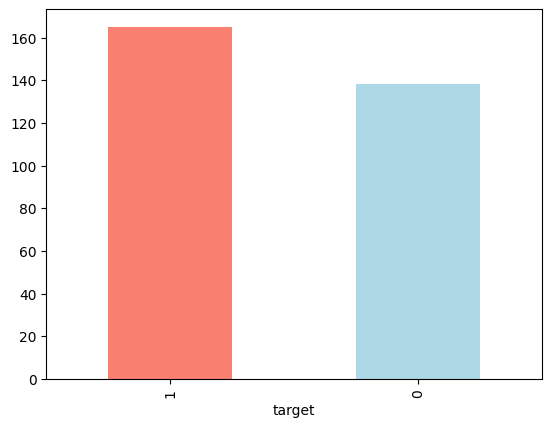

In [17]:
# visualizing the clases
df.target.value_counts().plot(kind="bar", color=["salmon","lightblue"]);

In [18]:
# let us have more information about our data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [20]:
# do we have not numeric columns 
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [21]:
# describe our data numerically
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Heart Disease Frequency according to sex 

In [22]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [23]:
# compare sex with target
pd.crosstab(df.target,df.sex)

sex,0,1
target,,
0,24,114
1,72,93


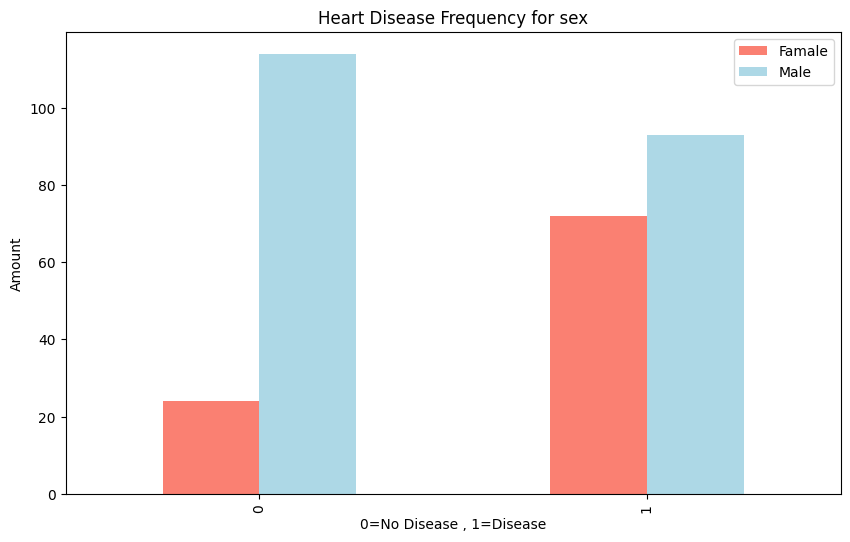

In [26]:
# create plot of  acrosstab
pd.crosstab(df.target,df.sex).plot(kind="bar",
                                   color=["salmon","lightblue"],
                                   figsize=(10,6))
plt.title("Heart Disease Frequency for sex")
plt.xlabel("0=No Disease , 1=Disease")
plt.ylabel("Amount")
plt.legend(["Famale","Male"]);